#  Bi Modal road Network Design (BMND) Example Notebook

This notebook provide basic example to use the BMND.

## Import necessary functions and libraries

In [1]:
import warnings
import logging
from utils_traffic import *
from utils_network_processing import *
from utils_plotting import *
from utils_od_matrix_generator import generate_od_df
from config import parameter
from utils_traffic import *
from utils_plotting import *
from utils_optimization import *

warnings.filterwarnings('ignore')
logging.getLogger("aequilibrae").setLevel(logging.ERROR)

## Network importation and plotting

To import and plot the toys network use `utils_network_processing.py` and `utils_plotting.py`.

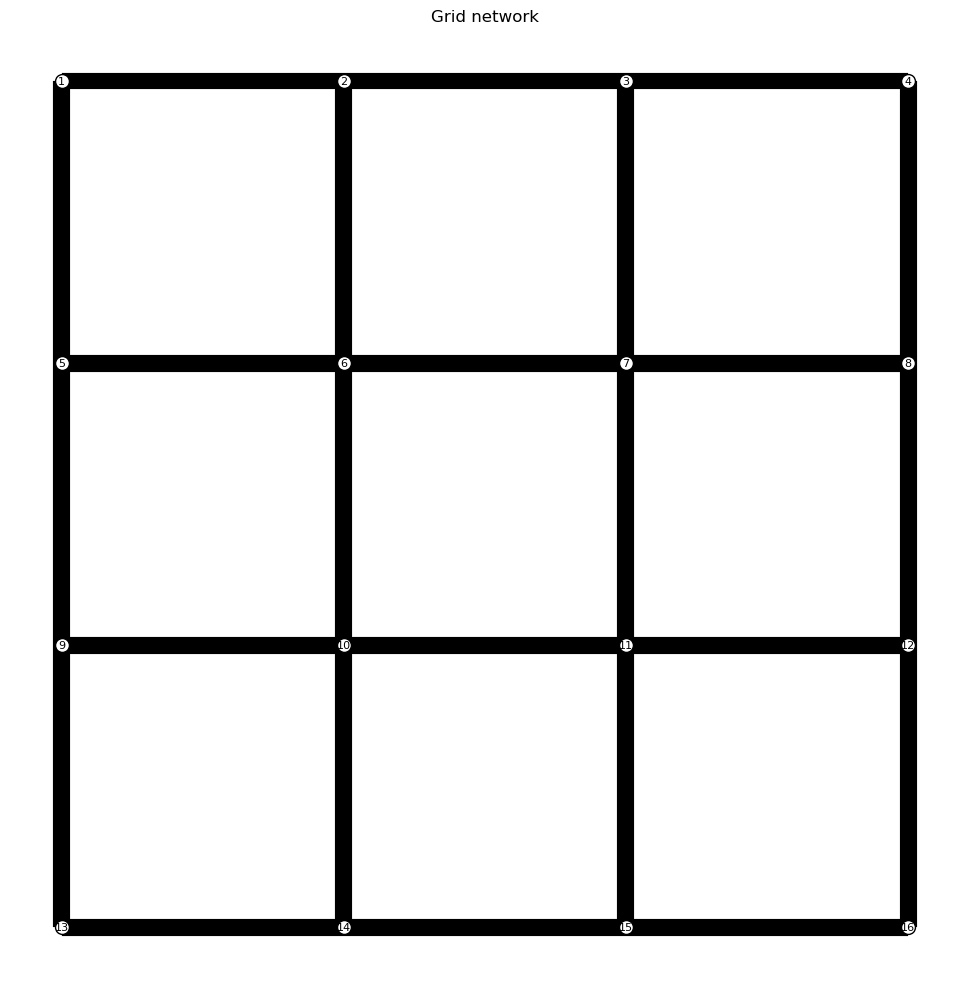

In [2]:
# load test scenario based on type of network (here "grid"), type of od matrix (here "CORNER_2") and max demand for od pairs (here 4000)
edge_df, node_df, od_df = load_test_scenario("grid", "CORNER_2", 4000)

plot_network(edge_df, node_df, node_id_col='id', base_width=1, node_label=True, title=f"Grid network")

We can also plot different variables like the slope or the green overlap of the edges.

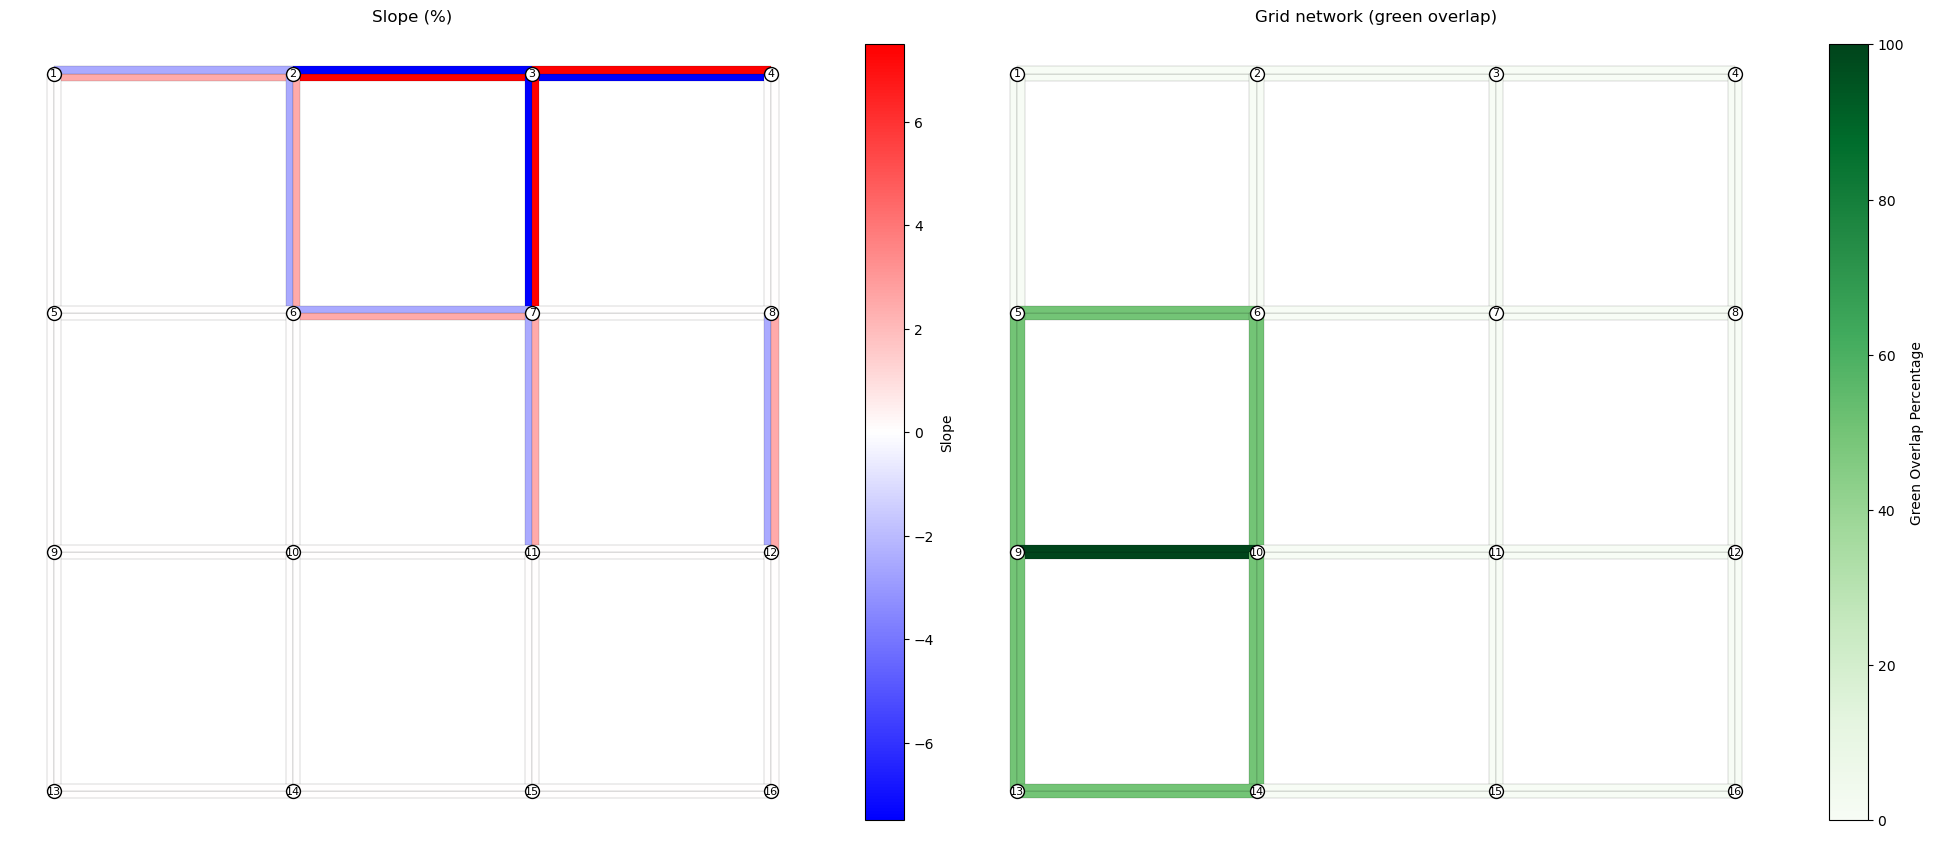

In [3]:
fig, ax = plt.subplots(1,2, figsize=(20,10))
plot_network(edge_df, node_df, node_id_col='id',base_width=1, node_label=True, title="Slope (%)", ax=ax[0], color_col_num="slope", cmap="bwr")
plot_network(edge_df, node_df, node_id_col='id', base_width=1, node_label=True, title=f"Grid network (green overlap)", ax=ax[1], color_col_num="green_overlap_percentage", cmap="Greens")

The `plot_od_matrix()` can also be used to visualize OD matrix.

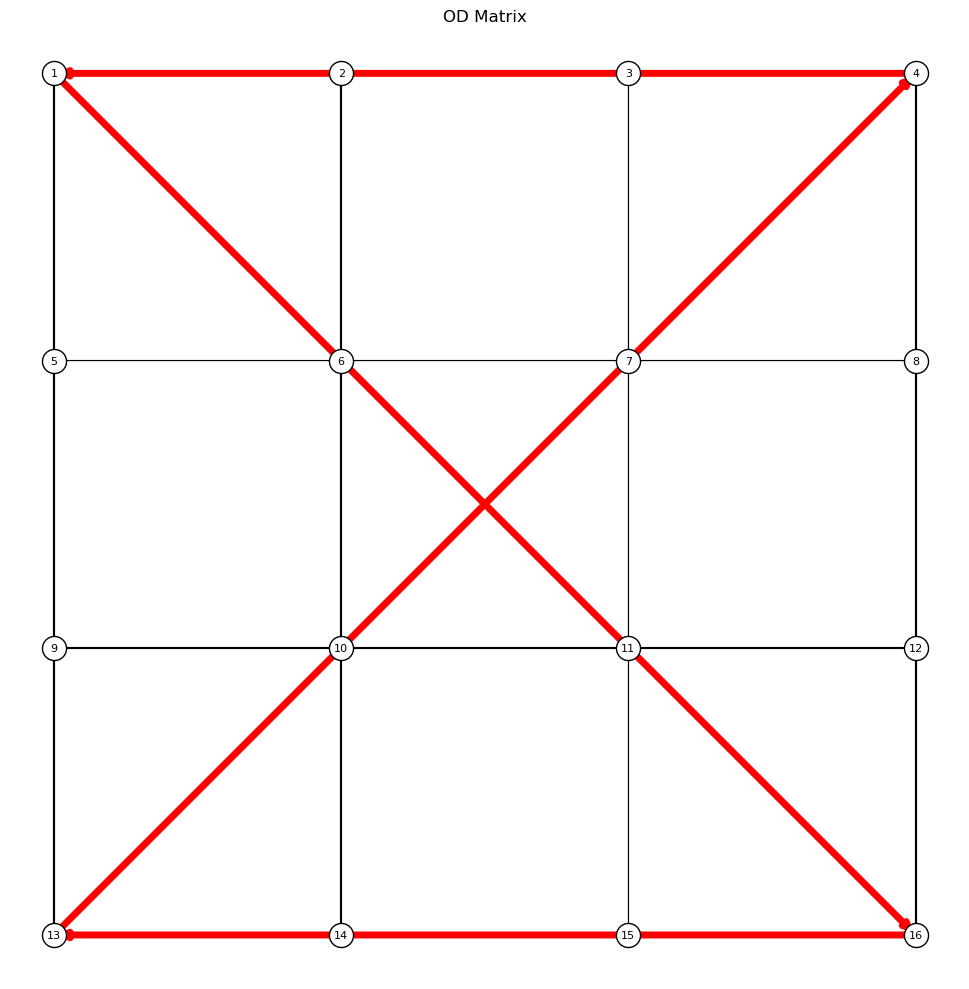

In [4]:
plot_od_matrix(convert_to_eaquilibrae_od_matrix(od_df), edge_df, node_df)

## Run the design model

To run the design model we use the `utils_optimization.py` file and the `reverse_growth_optimization()` function.

In [5]:
edge_df_results, results_df_opt = reverse_growth_optimization(edge_df, node_df, od_df, limit=48, CAP=True) # CAP parameter is used to switch between base model and capacity aware model

Mode shares with skimming: Car = 96.996 %, Bike = 3.004%
Iteration 47 - Removing bike lane on edge [33] with flow 235.9999439687846
